# Hack-O-Week | Week 5 & 6: Math for ML
**Linear Algebra** (vectors, matrices, dot product, eigenvalues) and **Calculus** (derivatives, gradients, chain rule for backprop).

Everything below is intuition-first and runs on NumPy + Matplotlib only.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)

## Part 1: Linear Algebra
### 1.1 Vectors
A vector is a list of numbers: a point, or an arrow with length and direction.

v + w      = [4 6]
2 * v      = [6 8]
||v|| (length) = 5.0


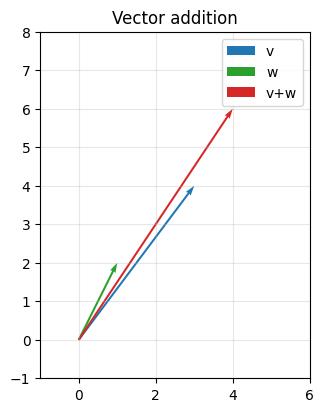

In [2]:
v = np.array([3, 4])
w = np.array([1, 2])
print("v + w      =", v + w)
print("2 * v      =", 2 * v)
print("||v|| (length) =", np.linalg.norm(v))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for vec, c, lab in [(v, 'tab:blue', 'v'), (w, 'tab:green', 'w'), (v + w, 'tab:red', 'v+w')]:
    ax.quiver(0, 0, *vec, angles='xy', scale_units='xy', scale=1, color=c, label=lab)
ax.set_xlim(-1, 6); ax.set_ylim(-1, 8); ax.grid(alpha=.3); ax.legend(); ax.set_aspect('equal')
ax.set_title("Vector addition")
plt.show()

### 1.2 Dot product
`a . b = sum(a_i * b_i) = |a||b|cos(theta)`. It measures **how much two vectors point the same way** (the core of similarity and of every neuron: `w . x + b`).

In [3]:
a = np.array([1, 0]); b = np.array([1, 1]); c = np.array([0, 1])
def cos_sim(x, y): return x @ y / (np.linalg.norm(x) * np.linalg.norm(y))
print("a.b =", a @ b, "| cos =", round(cos_sim(a, b), 3), "| angle =", round(np.degrees(np.arccos(cos_sim(a, b))), 1), "deg")
print("a.c =", a @ c, "(orthogonal -> 0)")

# a single neuron is a dot product
x = np.array([0.5, -1.0, 2.0]); weights = np.array([0.4, 0.3, 0.9]); bias = 0.1
print("neuron pre-activation:", weights @ x + bias)

a.b = 1 | cos = 0.707 | angle = 45.0 deg
a.c = 0 (orthogonal -> 0)
neuron pre-activation: 1.8000000000000003


### 1.3 Matrices as transformations
A matrix **moves space**: it stretches, rotates, and shears every vector. `A @ x` applies the transformation.

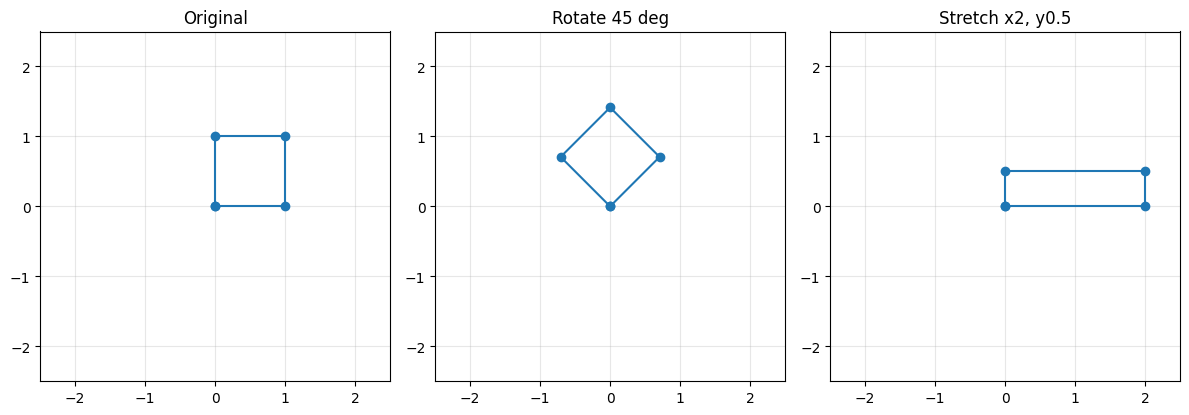

A @ B =
 [[2 1]
 [4 3]]
A.T   =
 [[1 3]
 [2 4]]
det(A) = -2.0 | inv(A) =
 [[-2.   1. ]
 [ 1.5 -0.5]]


In [4]:
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])   # rotation
S = np.array([[2, 0], [0, 0.5]])                                                  # stretch
square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, M, t in zip(axs, [np.eye(2), R, S], ["Original", "Rotate 45 deg", "Stretch x2, y0.5"]):
    p = M @ square
    ax.plot(p[0], p[1], 'o-'); ax.set_title(t); ax.grid(alpha=.3); ax.set_aspect('equal')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

A = np.array([[1, 2], [3, 4]]); B = np.array([[0, 1], [1, 0]])
print("A @ B =\n", A @ B)
print("A.T   =\n", A.T)
print("det(A) =", round(np.linalg.det(A), 3), "| inv(A) =\n", np.linalg.inv(A))

### 1.4 Eigenvalues & eigenvectors (intuition)
Most vectors change direction under a matrix. **Eigenvectors don't**: they only get scaled, by their **eigenvalue**: `A v = lambda v`. They are the matrix's "natural axes" (this is exactly what PCA uses).

eigenvalues : [3.618 1.382]
eigenvectors (columns):
 [[ 0.851 -0.526]
 [ 0.526  0.851]]
A @ v0 = [3.078 1.902]   lambda*v0 = [3.078 1.902]
A @ v1 = [-0.727  1.176]   lambda*v1 = [-0.727  1.176]


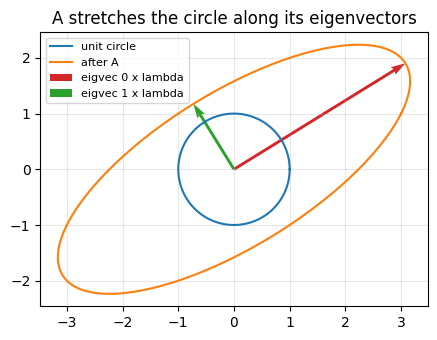

In [5]:
A = np.array([[3, 1], [1, 2]])
vals, vecs = np.linalg.eig(A)
print("eigenvalues :", vals)
print("eigenvectors (columns):\n", vecs)
for i in range(2):
    print(f"A @ v{i} = {A @ vecs[:, i]}   lambda*v{i} = {vals[i] * vecs[:, i]}")

theta = np.linspace(0, 2*np.pi, 200)
circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipse = A @ circle
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*circle, label="unit circle"); ax.plot(*ellipse, label="after A")
for i, c in enumerate(['tab:red', 'tab:green']):
    ax.quiver(0, 0, *(vals[i] * vecs[:, i]), angles='xy', scale_units='xy', scale=1, color=c, label=f"eigvec {i} x lambda")
ax.set_aspect('equal'); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title("A stretches the circle along its eigenvectors")
plt.show()

## Part 2: Calculus
### 2.1 Derivative = slope
The derivative `f'(x)` is the instantaneous rate of change. We compare an analytic derivative to a numerical one.

analytic f'(2) = 7 | numeric = 7.0


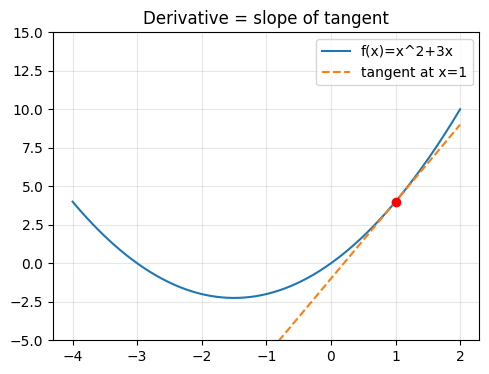

In [6]:
f  = lambda x: x**2 + 3*x
df = lambda x: 2*x + 3
num_d = lambda f, x, h=1e-5: (f(x + h) - f(x - h)) / (2*h)
print("analytic f'(2) =", df(2), "| numeric =", round(num_d(f, 2), 5))

x = np.linspace(-4, 2, 200); x0 = 1
tangent = f(x0) + df(x0) * (x - x0)
plt.figure(figsize=(5.5, 4))
plt.plot(x, f(x), label="f(x)=x^2+3x"); plt.plot(x, tangent, '--', label=f"tangent at x={x0}")
plt.scatter([x0], [f(x0)], color='red', zorder=3); plt.ylim(-5, 15); plt.grid(alpha=.3); plt.legend()
plt.title("Derivative = slope of tangent"); plt.show()

### 2.2 Gradients
With many inputs, the **gradient** is the vector of partial derivatives. It points in the direction of steepest ascent, so we step the opposite way to minimise: **gradient descent**.

start (3,2) -> end [0. 0.] (true minimum is (0,0))


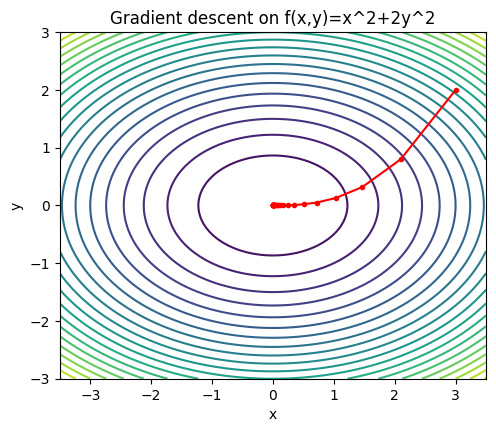

In [7]:
f2 = lambda x, y: x**2 + 2*y**2
grad = lambda p: np.array([2*p[0], 4*p[1]])
p = np.array([3.0, 2.0]); lr = 0.15; path = [p.copy()]
for _ in range(25):
    p = p - lr * grad(p); path.append(p.copy())
path = np.array(path)
print("start (3,2) -> end", path[-1], "(true minimum is (0,0))")

gx, gy = np.meshgrid(np.linspace(-3.5, 3.5, 100), np.linspace(-3, 3, 100))
plt.figure(figsize=(5.5, 4.5))
plt.contour(gx, gy, f2(gx, gy), levels=20, cmap='viridis')
plt.plot(path[:, 0], path[:, 1], 'ro-', ms=3); plt.title("Gradient descent on f(x,y)=x^2+2y^2")
plt.xlabel("x"); plt.ylabel("y"); plt.show()

### 2.3 Chain rule & backpropagation intuition
If `L = f(g(x))`, then `dL/dx = dL/dg * dg/dx`. Backprop is just this rule applied layer by layer, **from the loss backwards**.

Tiny network: `z = w*x + b`, `a = sigmoid(z)`, `L = (a - y)^2`.

In [8]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))
x, y = 1.5, 1.0
w, b = 0.2, -0.1

# forward
z = w*x + b; a = sigmoid(z); L = (a - y)**2
# backward (chain rule)
dL_da = 2*(a - y)
da_dz = a*(1 - a)
dz_dw = x; dz_db = 1
dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db
print(f"forward: z={z:.3f}, a={a:.3f}, L={L:.4f}")
print(f"backprop: dL/dw={dL_dw:.5f}, dL/db={dL_db:.5f}")

# verify with numerical gradients
loss = lambda w, b: (sigmoid(w*x + b) - y)**2
print(f"numeric : dL/dw={num_d(lambda t: loss(t, b), w):.5f}, dL/db={num_d(lambda t: loss(w, t), b):.5f}")

forward: z=0.200, a=0.550, L=0.2026
backprop: dL/dw=-0.33427, dL/db=-0.22285
numeric : dL/dw=-0.33427, dL/db=-0.22285


### 2.4 Putting it together: train the neuron
Vectors/dot product (forward pass) + gradients/chain rule (backward pass) = learning.

learned w: [ 2.26  -1.092] b: 0.466 | accuracy: 1.0


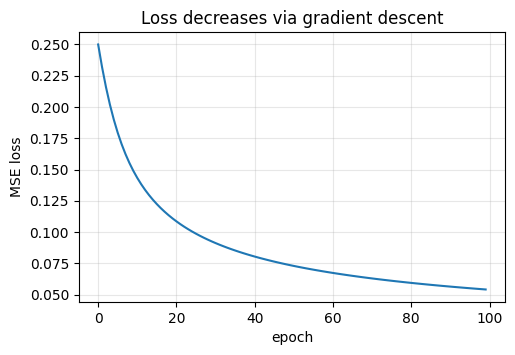

In [9]:
rng = np.random.default_rng(0)
X = rng.normal(size=(200, 2))
y = (X @ np.array([2.0, -1.0]) + 0.5 > 0).astype(float)     # true rule

w = np.zeros(2); b = 0.0; lr = 0.5; losses = []
for epoch in range(100):
    a = sigmoid(X @ w + b)                    # forward: dot product
    losses.append(np.mean((a - y)**2))
    dz = 2*(a - y) * a*(1 - a) / len(y)       # chain rule
    w -= lr * (X.T @ dz); b -= lr * dz.sum()  # gradient step
acc = np.mean((sigmoid(X @ w + b) > .5) == y)
print("learned w:", w, "b:", round(b, 3), "| accuracy:", acc)

plt.figure(figsize=(5.5, 3.5)); plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("MSE loss")
plt.title("Loss decreases via gradient descent"); plt.grid(alpha=.3); plt.show()

## Summary
| Concept | One-line intuition | Used in ML for |
|---|---|---|
| Vector | list of numbers / arrow | features, weights, embeddings |
| Dot product | alignment of two vectors | neurons, similarity |
| Matrix | transforms space | layers, data tables |
| Eigenvalues | stretch factors along natural axes | PCA, stability |
| Derivative | slope | sensitivity of loss |
| Gradient | direction of steepest ascent | gradient descent |
| Chain rule | multiply local slopes | backpropagation |